In [15]:
from google.colab import drive
import zipfile
import os

drive.mount('/content/drive')

print("Unzipping the clean, leak-free dataset...")
if not os.path.exists("/content/processed_clean/training"):
    with zipfile.ZipFile("/content/drive/MyDrive/Colab Notebooks/processed_clean.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/processed_clean")
    print("Extraction complete!")
else:
    print("Dataset already unzipped.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Unzipping the clean, leak-free dataset...
Dataset already unzipped.


In [16]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models,callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
from sklearn.metrics import ( confusion_matrix,
    classification_report,
    roc_curve,auc)
print(f"   TensorFlow version : {tf.__version__}")
print(f"   Keras version      : {keras.__version__}")
print()
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus}")
else:
    print("No GPU detected — using CPU")
tf.random.set_seed(42)
np.random.seed(42)
print()
print("Random seed set to 42 — results will be reproducible")

   TensorFlow version : 2.20.0
   Keras version      : 3.13.2

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Random seed set to 42 — results will be reproducible


In [18]:
# Paths
PROCESSED_ROOT = Path("/content/processed_clean")
TRAIN_DIR      = PROCESSED_ROOT / "training"
VAL_DIR        = PROCESSED_ROOT / "validation"
TEST_DIR       = PROCESSED_ROOT / "testing"
MODELS_DIR     = Path("../models")
RESULTS_DIR    = Path("../results")

# Create directories
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

#  Hyperparameters
IMG_SIZE      = (128, 128)
IMG_SHAPE     = (128, 128, 3)
BATCH_SIZE    = 32            # Files processed together in one training step
EPOCHS        = 30            # Maximum training rounds
LEARNING_RATE = 0.001         # How fast the model adjusts its weights
DROPOUT_RATE  = 0.3           # Fraction of neurons randomly disabled each step

# Model save path
MODEL_SAVE_PATH = MODELS_DIR / "vocal_armor_best.keras"

# Verify processed data exists
print("Checking processed spectrogram folders...")
print()

all_good = True
for split in ["training", "validation", "testing"]:
    for label in ["real", "fake"]:
        folder = PROCESSED_ROOT / split / label
        count  = len(list(folder.glob("*.png"))) if folder.exists() else 0
        status = "✅" if count > 0 else "❌"
        print(f"  {status}  processed/{split}/{label:<12} → {count:>7,} images")
        if count == 0:
            all_good = False

print()
if all_good:
    print("All folders found! Ready to train.")
else:
    print("Some folders are empty. Make sure Cell 12 in notebook 01 completed fully.")

print()
print("Hyperparameters:")
print(f"Image size     : {IMG_SIZE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Max epochs     : {EPOCHS}")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Dropout rate   : {DROPOUT_RATE}")

Checking processed spectrogram folders...

  ✅  processed/training/real         →   7,059 images
  ✅  processed/training/fake         →   7,133 images
  ✅  processed/validation/real         →     903 images
  ✅  processed/validation/fake         →     876 images
  ✅  processed/testing/real         →     838 images
  ✅  processed/testing/fake         →     912 images

All folders found! Ready to train.

Hyperparameters:
Image size     : (128, 128)
Batch size     : 32
Max epochs     : 30
Learning rate  : 0.001
Dropout rate   : 0.3


In [19]:
# Training generator WITH augmentation
train_data_gen = ImageDataGenerator(
    rescale = 1./255,        # Normalize pixels from [0,255] to [0,1]
)

eval_data_gen = ImageDataGenerator(rescale=1./255)
train_generator = train_data_gen.flow_from_directory(
    directory = TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,        # loads 32 images
    class_mode = 'binary',      # binary classifiation
    shuffle = True,
    seed = 42
)
val_generator = eval_data_gen.flow_from_directory(
    directory  = VAL_DIR,
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    shuffle    = False,           # Never shuffle validation
    seed       = 42
)
test_generator = eval_data_gen.flow_from_directory(
    directory  = TEST_DIR,
    target_size= IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'binary',
    shuffle    = False,           # Never shuffle test set
    seed       = 42
)
print("Data Loader Summary")
print(f"Class mapping       : {train_generator.class_indices}")
print(f"Training samples    : {train_generator.samples:,}")
print(f"Validation samples  : {val_generator.samples:,}")
print(f"Test samples        : {test_generator.samples:,}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Training steps/epoch: {train_generator.samples // BATCH_SIZE}")
print()
print("Class mapping explanation:")
print("0 = fake  (the folder named 'fake')")
print("1 = real  (the folder named 'real')")
print("Model output > 0.5 = REAL, ≤ 0.5 = FAKE")

Found 14192 images belonging to 2 classes.
Found 1779 images belonging to 2 classes.
Found 1750 images belonging to 2 classes.
Data Loader Summary
Class mapping       : {'fake': 0, 'real': 1}
Training samples    : 14,192
Validation samples  : 1,779
Test samples        : 1,750
Batch size          : 32
Training steps/epoch: 443

Class mapping explanation:
0 = fake  (the folder named 'fake')
1 = real  (the folder named 'real')
Model output > 0.5 = REAL, ≤ 0.5 = FAKE


Batch shape: (32, 128, 128, 3)
means: 32 images, each 128×128 pixels, 3 color channels
Pixel value range: min=0.000, max=1.000
labels in this batch: [0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1]
(0 = fake, 1 = real)


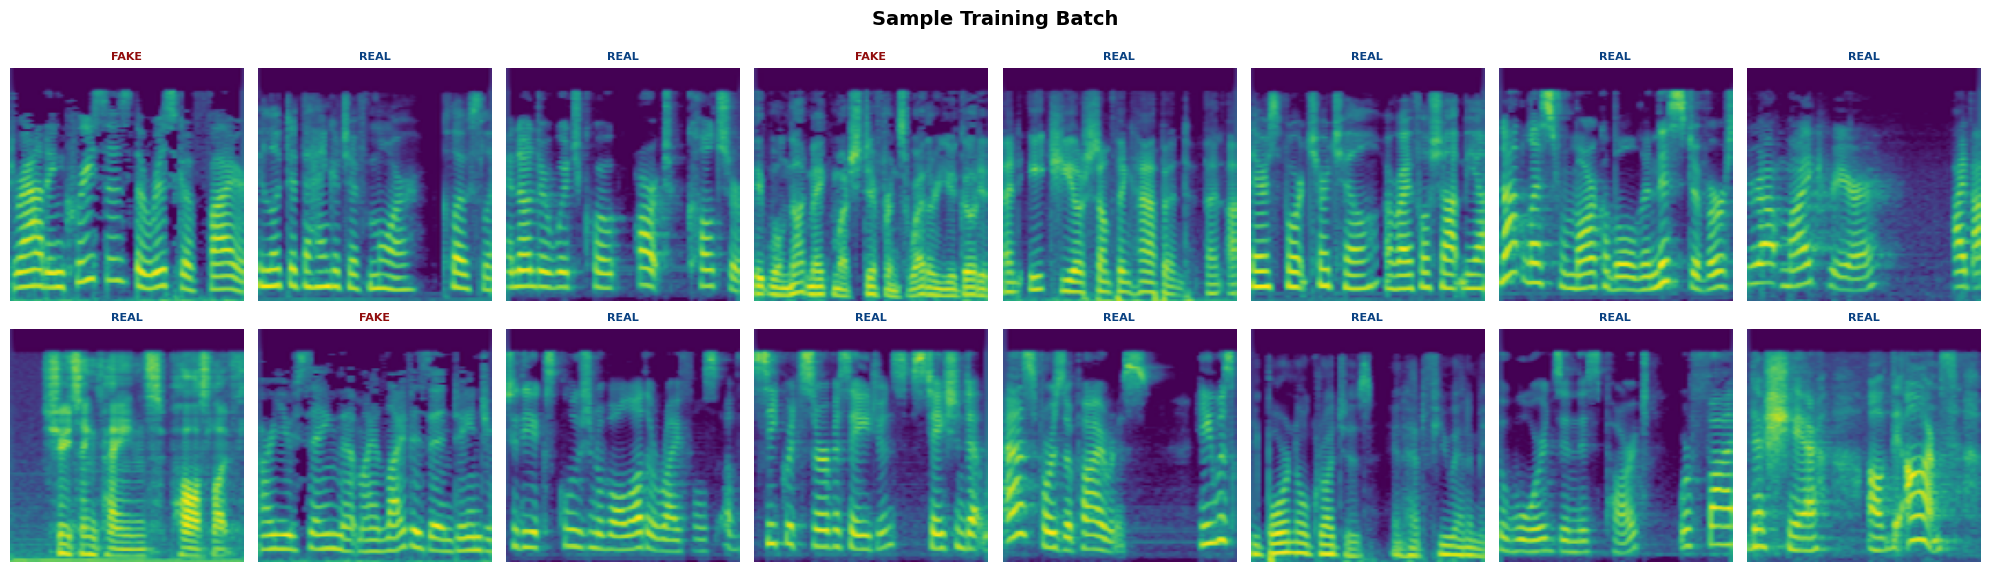

saved to : ../results/06_training_batch_sample.png


In [20]:
sample_images, sample_labels = next(train_generator)
print(f"Batch shape: {sample_images.shape}")
print(f"means: {sample_images.shape[0]} images, each {sample_images.shape[1]}×{sample_images.shape[2]} pixels, {sample_images.shape[3]} color channels")
print(f"Pixel value range: min={sample_images.min():.3f}, max={sample_images.max():.3f}")
print(f"labels in this batch: {sample_labels[:16].astype(int).tolist()}")
print(f"(0 = fake, 1 = real)")
# Plot first 16 images
label_names = {v: k for k, v in train_generator.class_indices.items()}
colors = {"fake": "#910C0C", "real" : "#094182"}
fig, axes = plt.subplots(2, 8, figsize = (20,6))
fig.suptitle("Sample Training Batch",fontsize=14, fontweight="bold")
for i ,ax in enumerate(axes.flat):
    if i < len(sample_images):
        ax.imshow(sample_images[i])
        label_name = label_names[int(sample_labels[i])]
        ax.set_title(label_name.upper(),fontsize=8,color=colors[label_name], fontweight="bold")
        ax.axis("off")

plt.tight_layout()
save_path = RESULTS_DIR / "06_training_batch_sample.png"
plt.savefig(save_path, dpi=150,bbox_inches="tight")
plt.show()
print(f"saved to : {save_path}")


In [21]:
def build_cnn (input_shape=IMG_SHAPE, dropout_rate=DROPOUT_RATE):
    model = models.Sequential(name="VocalArmor_CNN",layers=[
        layers.Input(shape=input_shape),
        #Detect Basic Patterns (edges, textures)
        # 32 filters scanning for low-level frequency patterns

        layers.Conv2D(32,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(dropout_rate),
        #  Detect Complex Patterns
        # 64 filters combining prev Block patterns into more complex features

        layers.Conv2D(64, (3,3), activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu',padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(dropout_rate),
        # Detect Deepfake-Specific Artifacts
        # 128 filters for subtle high-level AI voice artifacts
        layers.Conv2D(128,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128,(3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(dropout_rate),

        #FLATTEN: 2D → 1D
        layers.GlobalAveragePooling2D(),      #Better than Flatten for generalization

        #DECISION HEAD
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        # Output: 0.0 = definitely FAKE, 1.0 = definitely REAL
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_cnn()
print("Vocal-Armor CNN Architecture:")
model.summary()

Vocal-Armor CNN Architecture:


Model: "VocalArmor_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 339,361 (1.29 MB)

 Trainable params: 337,953 (1.29 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [22]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)
print("Model compiled successfully!")
print("Training configuration:")
print(f"Optimizer      : Adam")
print(f"Learning rate  : {LEARNING_RATE}")
print(f"Loss function  : binary_crossentropy")
print(f"Metrics tracked: accuracy")
print()
print("Model is ready to train")

Model compiled successfully!
Training configuration:
Optimizer      : Adam
Learning rate  : 0.001
Loss function  : binary_crossentropy
Metrics tracked: accuracy

Model is ready to train


In [23]:
training_callbacks = [
    # Callback 1: Save the best model automatically
    callbacks.ModelCheckpoint(
        filepath = str(MODEL_SAVE_PATH),
        monitor= 'val_accuracy',
        save_best_only= True,
        mode= 'max',
        verbose= 1
    ),
    # Callback 2: Stop training if no improvement
    callbacks.EarlyStopping(
        monitor= 'val_accuracy',
        patience= 7,    # Wait 7 epochs before stopping
        restore_best_weights= True,
        verbose= 1
    ),
    # Callback 3: Reduce learning rate when stuck
    callbacks.ReduceLROnPlateau(
        monitor= 'val_loss',
        factor = 0.5,
        patience= 3,   # Wait 3 epochs before reducing
        min_lr= 1e-7,  # Never go below this learning rate
        verbose= 1
    ),
        # Callback 4: Log training history to CSV
    callbacks.CSVLogger(
        filename= str(RESULTS_DIR / "training_log.csv"),
        append = False
    )
]
print("Callbacks configured:")
print(f"1. ModelCheckpoint   → saves best model to: {MODEL_SAVE_PATH}")
print(f"2. EarlyStopping     → stops if no improvement for 7 epochs")
print(f"3. ReduceLROnPlateau → halves learning rate if stuck for 3 epochs")
print(f"4. CSVLogger         → logs all metrics to: results/training_log.csv")

Callbacks configured:
1. ModelCheckpoint   → saves best model to: ../models/vocal_armor_best.keras
2. EarlyStopping     → stops if no improvement for 7 epochs
3. ReduceLROnPlateau → halves learning rate if stuck for 3 epochs
4. CSVLogger         → logs all metrics to: results/training_log.csv


In [24]:
print("Starting Vocal-Armor CNN Training...")
print(f"Training on   : {train_generator.samples:,} spectrogram images")
print(f"Validating on : {val_generator.samples:,} spectrogram images")
print(f"Max epochs    : {EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")
print()
print("val_accuracy should increase each epoch")
print("Target: val_accuracy > 0.85 (85%)")
print()
history = model.fit(
    train_generator,
    epochs = EPOCHS,
    validation_data = val_generator,
    callbacks = training_callbacks,
    verbose = 1
)
print()
print("Training complete")
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1
final_epochs = len(history.history['val_accuracy'])

print(f"Training Summary:")
print(f"total epochs run : {final_epochs}")
print(f"best validationaccuracy : {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"best epoch : {best_epoch}")
print(f"model saved to : {MODEL_SAVE_PATH}")

if best_val_acc >= 0.85:
    print("You hit the 85% target! Proceed to evaluation.")

elif best_val_acc >= 0.75:
    print("try accuracy improvement techniques.")
else:
    print("improvement techniques will help.")

Starting Vocal-Armor CNN Training...
Training on   : 14,192 spectrogram images
Validating on : 1,779 spectrogram images
Max epochs    : 30
Batch size    : 32

val_accuracy should increase each epoch
Target: val_accuracy > 0.85 (85%)

Epoch 1/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8714 - loss: 0.2859
Epoch 1: val_accuracy improved from None to 0.50646, saving model to ../models/vocal_armor_best.keras

Epoch 1: finished saving model to ../models/vocal_armor_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 81s 153ms/step - accuracy: 0.9307 - loss: 0.1676 - val_accuracy: 0.5065 - val_loss: 8.9295 - learning_rate: 0.0010
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9829 - loss: 0.0483
Epoch 2: val_accuracy improved from 0.50646 to 0.97752, saving model to ../models/vocal_armor_best.keras

Epoch 2: finished saving model to ../models/vocal_armor_best.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 51s 114ms/step - accuracy: 0.9853 - loss: 0.0432 - val_accuracy: 0.9775 - 

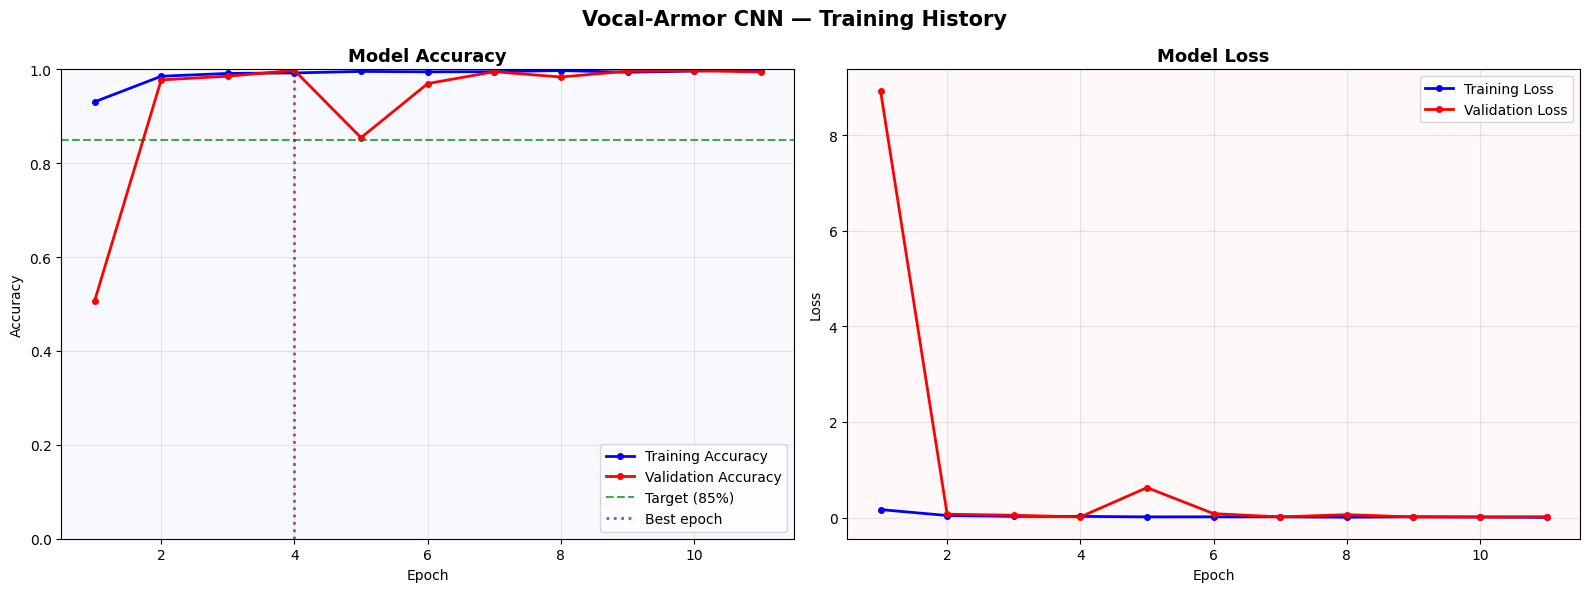

Saved to: ../results/07_training_history.png

Overfitting Analysis:
Final training accuracy : 0.9986 (99.86%)
Final validation accuracy : 0.9944 (99.44%)
Gap (train - val) : 0.0042 (0.42%)

Gap < 5% — No significant overfitting.


In [25]:
epochs_ran = range(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Vocal-Armor CNN — Training History",
             fontsize=15, fontweight="bold")

# Accuracy Plot
axes[0].plot(epochs_ran, history.history['accuracy'],
             'b-o', markersize=4, label='Training Accuracy', linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'],
             'r-o', markersize=4, label='Validation Accuracy', linewidth=2)
axes[0].axhline(y=0.85, color='green', linestyle='--',
                linewidth=1.5, label='Target (85%)', alpha=0.7)
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#F8F9FF')

# Mark best epoch
best_epoch_idx = history.history['val_accuracy'].index(
    max(history.history['val_accuracy']))
axes[0].axvline(x=best_epoch_idx + 1, color='purple',
                linestyle=':', linewidth=2, alpha=0.7, label='Best epoch')
axes[0].legend(loc='lower right')

# Loss Plot
axes[1].plot(epochs_ran, history.history['loss'],
             'b-o', markersize=4, label='Training Loss', linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'],
             'r-o', markersize=4, label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#FFF8F8')

plt.tight_layout()
save_path = RESULTS_DIR / "07_training_history.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {save_path}")

# Gap analysis
final_train_acc = history.history['accuracy'][-1]
final_val_acc   = history.history['val_accuracy'][-1]
gap             = abs(final_train_acc - final_val_acc)

print()
print(f"Overfitting Analysis:")
print(f"Final training accuracy : {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"Final validation accuracy : {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"Gap (train - val) : {gap:.4f} ({gap*100:.2f}%)")
print()
if gap < 0.05:
    print("Gap < 5% — No significant overfitting.")
elif gap < 0.10:
    print("Gap 5-10% — Slight overfitting.")
else:
    print("Gap > 10% — Overfitting detected.")

In [26]:
print(f"Loading best model from: {MODEL_SAVE_PATH}")

best_model = keras.models.load_model(str(MODEL_SAVE_PATH))

print("Model loaded successfully!")
print()

# Quick sanity check — evaluate on validation set
val_loss, val_accuracy = best_model.evaluate(val_generator, verbose=0)

print(f"Best Model — Validation Performance:")
print(f"Validation Loss : {val_loss:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print()
print("This is the model we will use for all evaluations below.")

Loading best model from: ../models/vocal_armor_best.keras
Model loaded successfully!

Best Model — Validation Performance:
Validation Loss : 0.0141
Validation Accuracy : 0.9978 (99.78%)

This is the model we will use for all evaluations below.


In [27]:
print("Evaluating on test set (data model has NEVER seen)...")
print()

# Reset generator to start from beginning
test_generator.reset()

# Get test set loss and accuracy
test_loss, test_accuracy = best_model.evaluate(test_generator, verbose=1)

print()
print("=" * 50)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print("=" * 50)
print()

# Get raw predictions for detailed analysis
test_generator.reset()
y_pred_proba = best_model.predict(test_generator, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
y_true = test_generator.classes

print()
print(f"Predictions summary:")
print(f"Total test samples : {len(y_true):,}")
print(f"Predicted FAKE (0) : {(y_pred == 0).sum():,}")
print(f"Predicted REAL (1) : {(y_pred == 1).sum():,}")
print(f"Actual FAKE (0) : {(y_true == 0).sum():,}")
print(f"Actual REAL (1) : {(y_true == 1).sum():,}")

Evaluating on test set (data model has NEVER seen)...

55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.9977 - loss: 0.0067

Test Loss : 0.0067
Test Accuracy : 0.9977  (99.77%)

55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step

Predictions summary:
Total test samples : 1,750
Predicted FAKE (0) : 908
Predicted REAL (1) : 842
Actual FAKE (0) : 912
Actual REAL (1) : 838


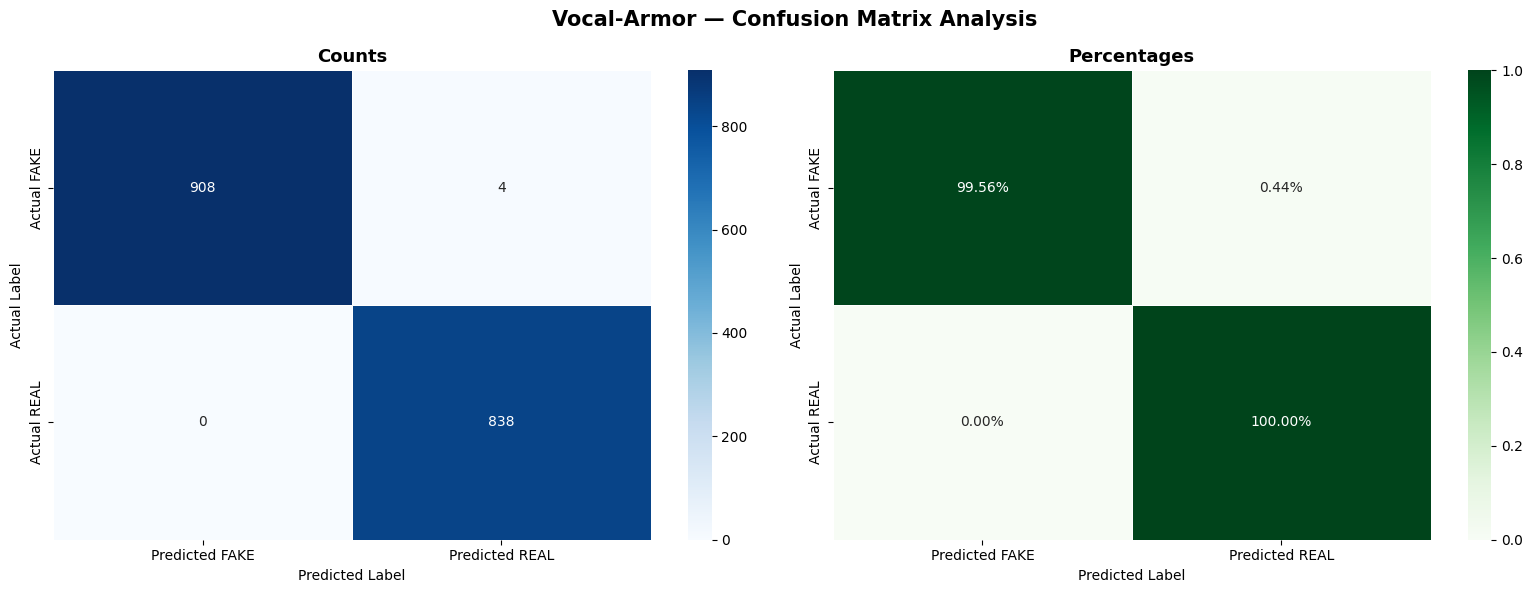

Saved to: ../results/08_confusion_matrix.png

Confusion Matrix Breakdown:
True  Negative (Correctly caught FAKE) : 908 
False Positive (FAKE called REAL)      : 4
False Negative (REAL called FAKE)      : 0
True  Positive (Correctly kept REAL)   : 838

Missed deepfakes (False Negatives)  : 0 


In [31]:
# Compute confusion matrix
cm           = confusion_matrix(y_true, y_pred)
class_names  = list(test_generator.class_indices.keys())  # ['fake', 'real']

# Plot confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Vocal-Armor — Confusion Matrix Analysis",
             fontsize=15, fontweight="bold")

# Raw counts
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    xticklabels = [f'Predicted {c.upper()}' for c in class_names],
    yticklabels = [f'Actual {c.upper()}'    for c in class_names],
    ax = axes[0],
    linewidths  = 0.5
)
axes[0].set_title('Counts', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Normalized (percentages)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm,
    annot = True,
    fmt = '.2%',
    cmap = 'Greens',
    xticklabels = [f'Predicted {c.upper()}' for c in class_names],
    yticklabels = [f'Actual {c.upper()}'    for c in class_names],
    ax = axes[1],
    linewidths  = 0.5
)
axes[1].set_title('Percentages', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
save_path = RESULTS_DIR / "08_confusion_matrix.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {save_path}")

# ── Extract individual numbers ────────────────────────────────────────────
tn, fp, fn, tp = cm.ravel()
print()
print("Confusion Matrix Breakdown:")
print(f"True  Negative (Correctly caught FAKE) : {tn:,} ")
print(f"False Positive (FAKE called REAL)      : {fp:,}")
print(f"False Negative (REAL called FAKE)      : {fn:,}")
print(f"True  Positive (Correctly kept REAL)   : {tp:,}")
print()
print(f"Missed deepfakes (False Negatives)  : {fn:,} ")

Full Classification Report:

              precision    recall  f1-score   support

        FAKE     1.0000    0.9956    0.9978       912
        REAL     0.9952    1.0000    0.9976       838

    accuracy                         0.9977      1750
   macro avg     0.9976    0.9978    0.9977      1750
weighted avg     0.9977    0.9977    0.9977      1750



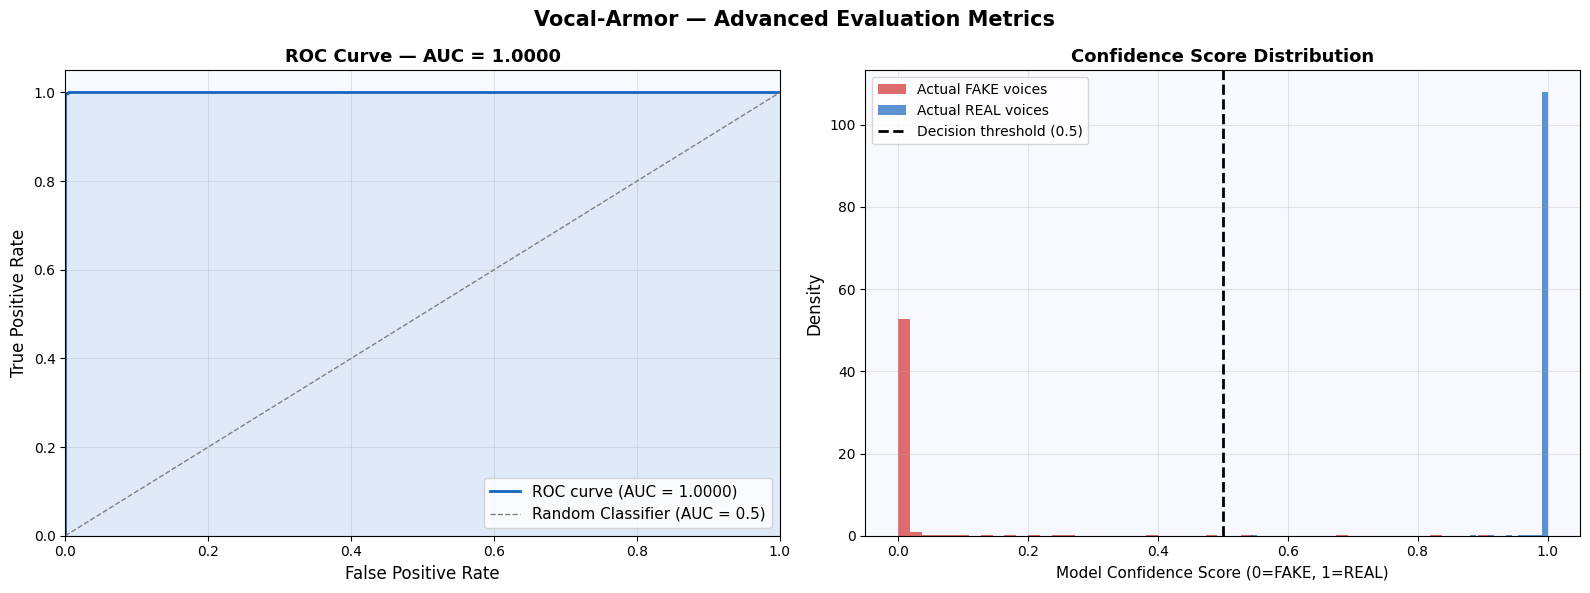

Saved to: ../results/09_roc_and_confidence.png

AUC Score: 1.0000
Excellent AUC!


In [32]:
print("Full Classification Report:")
print()
report = classification_report(
    y_true,
    y_pred,
    target_names = ["FAKE", "REAL"],
    digits = 4
)
print(report)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Vocal-Armor — Advanced Evaluation Metrics",
             fontsize=15, fontweight="bold")

# ROC Curve plot
axes[0].plot(fpr, tpr, color='#1565C0', lw=2,
             label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1,
             linestyle='--', label='Random Classifier (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#1565C0')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title(f'ROC Curve — AUC = {roc_auc:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#F8F9FF')

# Confidence Distribution
fake_probs = y_pred_proba[y_true == 0].flatten()
real_probs = y_pred_proba[y_true == 1].flatten()

axes[1].hist(fake_probs, bins=50, alpha=0.7, color='#D32F2F',
             label='Actual FAKE voices', density=True)
axes[1].hist(real_probs, bins=50, alpha=0.7, color='#1565C0',
             label='Actual REAL voices', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--',
                linewidth=2, label='Decision threshold (0.5)')
axes[1].set_xlabel('Model Confidence Score (0=FAKE, 1=REAL)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Confidence Score Distribution',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#F8F9FF')

plt.tight_layout()
save_path = RESULTS_DIR / "09_roc_and_confidence.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to: {save_path}")
print()
print(f"AUC Score: {roc_auc:.4f}")
if roc_auc >= 0.90:
    print("Excellent AUC!")
elif roc_auc >= 0.85:
    print("Very good AUC")
elif roc_auc >= 0.75:
    print("Decent AUC")
else:
    print("Low AUC")

In [33]:
# Results files
print("Files saved to results/:")
for f in sorted(RESULTS_DIR.glob("*.png")):
    print(f"{f.name}")

print()
print("Models saved:")
for f in sorted(MODELS_DIR.glob("*.keras")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"{f.name:<40} ({size_mb:.1f} MB)")


Files saved to results/:
06_training_batch_sample.png
07_training_history.png
08_confusion_matrix.png
09_roc_and_confidence.png

Models saved:
vocal_armor_best.keras                   (4.0 MB)
